# LLR Photometric Redshift & Galactic Physics Pipeline

這個 Notebook 實作了利用局部線性迴歸 (Local Linear Regression, LLR) 從光學波段測光資料推算測光紅移 ($z_{phot}$) 的流程（類似於 SDSS DR12 所採用的方法），並進而推算宇宙學距離與絕對物理量。

### Step 1: Data Ingestion & Parameter Setup
在此步驟中我們載入訓練集 (`train_data.csv`) 與目標集 (`target_data.csv`)。為確保流程能獨立測試，若找不到檔案，將自動生成模擬的星系資料供後續使用。

In [1]:
MAG = 'Kron'

In [2]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import matplotlib.pyplot as plt
from dustmaps.sfd import SFDQuery
from astropy.coordinates import SkyCoord
from sklearn.model_selection import train_test_split

%matplotlib inline

# 載入資料集
try:
    df = pd.read_csv('../data/merged_training_ps1.csv')
    # df = df[df['spec_redshift'] <= 0.1]
    df = df[df['zWarning'] == 0]
    #filtered galaxy object
    df = df[(df['rMeanApMag'] - df['rMeanPSFMag']) < -0.1]
    df = df[df['spec_redshift'] >= 0]
    train_df, target_df = train_test_split(df, test_size=0.4)
    print("成功載入 train_data.csv 與 target_data.csv！")
    print(len(df))
except FileNotFoundError:
    print("找不到資料集檔案")

成功載入 train_data.csv 與 target_data.csv！
306671


In [3]:
bands = ['g', 'r', 'i', 'z', 'y']
for b in bands:
    train_df = train_df[train_df[f'{b}Mean{MAG}Mag']!= -999.0]
    train_df = train_df[train_df[f'{b}Mean{MAG}MagErr']!= -999.0]
    train_df = train_df[np.isnan(train_df['spec_redshift']) == False]
    target_df = target_df[target_df[f'{b}Mean{MAG}Mag'] != -999.0]
    target_df = target_df[target_df[f'{b}Mean{MAG}MagErr'] != -999.0]
    target_df = target_df[np.isnan(target_df['spec_redshift']) == False]
train_df_2, target_df = train_test_split(target_df, test_size=0.5)

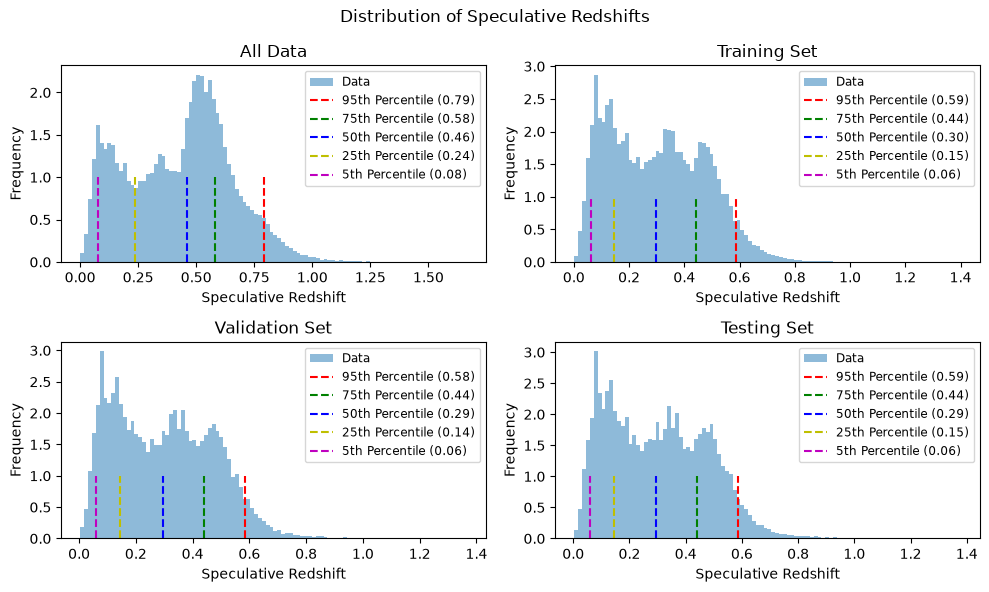

In [124]:
# merge as a single large figure
def plot_redshift_distribution(df, ax, title):
    ax.hist(df['spec_redshift'], bins=100, alpha=0.5, label='Data', density=True, cumulative=False)
    ax.vlines(np.percentile(df['spec_redshift'], 95), 0, 1, colors='r', linestyles='dashed', label=f'95th Percentile ({np.percentile(df["spec_redshift"], 95):.2f})')
    ax.vlines(np.percentile(df['spec_redshift'], 75), 0, 1, colors='g', linestyles='dashed', label=f'75th Percentile ({np.percentile(df["spec_redshift"], 75):.2f})')
    ax.vlines(np.percentile(df['spec_redshift'], 50), 0, 1, colors='b', linestyles='dashed', label=f'50th Percentile ({np.percentile(df["spec_redshift"], 50):.2f})')
    ax.vlines(np.percentile(df['spec_redshift'], 25), 0, 1, colors='y', linestyles='dashed', label=f'25th Percentile ({np.percentile(df["spec_redshift"], 25):.2f})')
    ax.vlines(np.percentile(df['spec_redshift'], 5), 0, 1, colors='m', linestyles='dashed', label=f'5th Percentile ({np.percentile(df["spec_redshift"], 5):.2f})')
    ax.set_title(f'{title}')
    ax.set_xlabel('Speculative Redshift')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize='small')
    # plt.savefig('spec_redshift_distribution.png', dpi=300)
fig = plt.figure(figsize=(10, 6))

for i, (data_read, title) in enumerate(zip([df, train_df, train_df_2, target_df], ['All Data', 'Training Set', 'Validation Set', 'Testing Set'])):
    ax = plt.subplot(2, 2, i + 1)
    plot_redshift_distribution(data_read, ax, title)
fig.suptitle(f'Distribution of Speculative Redshifts')
plt.tight_layout()
plt.savefig('spec_redshift_distribution.png', dpi=300)
plt.show()

In [125]:
print(len(train_df), len(train_df_2), len(target_df))

106698 35422 35422


### Step 2: Photometric Dereddening & Feature Engineering
在此我們進行「去紅化」處理 (`mag_dered = cModelMag - extinction`)，並構建機器學習所需的 5 維度特徵空間：一個去紅化 $r$ 波段星等以及四個顏色指數 ($u-g$, $g-r$, $r-i$, $i-z$)。最後使用 `StandardScaler` 將特徵標準化。

In [126]:
def extract_features(df):
    """
    計算去紅化星等並提取 5 維度的特徵空間。
    """
    df = df.copy()
    bands = ['g', 'r', 'i', 'z', 'y']
    
    # 1. 去紅化計算
    sfd = SFDQuery()
    coords = SkyCoord(ra = df['raMean'], dec = df['decMean'], unit = (u.deg, u.deg), frame = 'icrs')
    ebv = sfd(coords)
    coefficient = [3.172, 2.271, 1.682, 1.322, 1.087]
    extinction = [i*ebv for i in coefficient]
    for b, extinc in zip(bands, extinction):
        if f'{b}Mean{MAG}Mag' in df.columns:
            df[f'dered_{b}'] = df[f'{b}Mean{MAG}Mag'] - extinc
        else:
            raise ValueError(f"缺少 {b} 波段的資料")
            
    # 2. 計算 5D 測光特徵空間
    features = pd.DataFrame()
    features['mag_r'] = df['dered_r']
    features['g-r'] = df['dered_g'] - df['dered_r']
    features['r-i'] = df['dered_r'] - df['dered_i']
    features['i-z'] = df['dered_i'] - df['dered_z']
    features['z-y'] = df['dered_z'] - df['dered_y']
    # for b in bands:
    #    features[f'{b}_err'] = df[f'{b}MeanApMagErr']

    return df, features

# 提取特徵
train_df, train_features = extract_features(train_df)
train_df_2, train_features_2 = extract_features(train_df_2)
target_df, target_features = extract_features(target_df)

# 3. 使用 StandardScaler 進行標準化 
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
train_features_2_scaled = scaler.transform(train_features_2)
target_features_scaled = scaler.transform(target_features)

print("特徵工程與標準化完成！")

特徵工程與標準化完成！


### Step 3: The DR12 Local Linear Regression (LLR) Algorithm
利用最近鄰 (`NearestNeighbors`) 在訓練集中為每個目標星系尋找 $k=100$ 個最近的鄰居，接著對這 100 個鄰居套用局部線性迴歸 (`LinearRegression`) 並利用 $3\sigma$ 剔除異常值，最後預測出 $z_{phot}$ 及推估其誤差。

In [133]:
def calculate_photometric_redshift_llr(train_features, train_z_spec, target_features, k=100):
    """
    實作包含 Outlier Rejection 的局部線性迴歸演算法 (LLR)。
    """
    # 1. 初始化 NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k, algorithm='auto')
    nn.fit(train_features)
    
    z_phot_pred = np.zeros(len(target_features))
    z_phot_err = np.zeros(len(target_features))
    z_std = np.zeros(len(target_features))
    # 2. 針對「每一個」目標星系進行預測
    for i, target_feat in enumerate(target_features):
        # 尋找 k=100 個最近鄰
        distances, indices = nn.kneighbors([target_feat])
        neighbor_idx = indices[0]
        neighbor_redshifts = train_z_spec.iloc[neighbor_idx].values
        z_std[i] = (np.std(neighbor_redshifts))
        # 3. 提取特徵與真實紅移
        X_neighbors = train_features[neighbor_idx]
        y_neighbors = train_z_spec.iloc[neighbor_idx].values
        
        # 4. 首次擬合局部超平面
        lr = LinearRegression()
        lr.fit(X_neighbors, y_neighbors)
        
        # 5. Outlier Rejection Loop (剔除 > 3 sigma 殘差的鄰居)
        predictions = lr.predict(X_neighbors)
        residuals = np.abs(y_neighbors - predictions)
        std_residual = np.std(residuals)
        valid_mask = residuals < (3 * std_residual)
        
        # 防呆：如果剔除後鄰居過少，則不進行剔除
        if np.sum(valid_mask) > 10:
            X_clean, y_clean = X_neighbors[valid_mask], y_neighbors[valid_mask]
        else:
            X_clean, y_clean = X_neighbors, y_neighbors
            
        # 6. 利用剩下的鄰居重新擬合 (Re-fit)
        lr.fit(X_clean, y_clean)
        
        # 7. 預測目標星系的 z_phot (確保紅移不會小於0)
        z_pred = max(lr.predict([target_feat])[0], 0.0)
        z_phot_pred[i] = z_pred
        
        # 8. 儲存局部標準差作為誤差估計
        final_residuals = y_clean - lr.predict(X_clean)
        z_phot_err[i] = np.std(final_residuals)
    return z_phot_pred, z_phot_err, z_std

k_list = np.arange(50, 501, 50)
best = []
for k in k_list:
    print(f"開始進行 LLR 測光紅移推算，k={k}... (若資料量大可能需時數秒至數分鐘)")
    train_df_2['z_phot'], train_df_2['z_phot_err'], train_df_2['z_std'] = calculate_photometric_redshift_llr(
        train_features_scaled, 
        train_df['spec_redshift'], 
        train_features_2_scaled, 
        k=k
    )
    
    print("LLR 測光紅移計算完成！")
    valid_idx = np.isfinite(train_df_2['spec_redshift']) & np.isfinite(train_df_2['z_phot'])
    x = train_df_2['spec_redshift'].iloc[valid_idx]
    y = train_df_2['z_phot'].iloc[valid_idx]
    dz_norm = (y - x) / (1 + x)
    sigma_nmad = 1.48 * np.median(np.abs(dz_norm - np.median(dz_norm)))
    print(f"對於 k={k}，σ_NMAD 為 {sigma_nmad:.5f}")
    best.append((k, sigma_nmad))

best = sorted(best, key=lambda x: x[1])
print(f"最佳 k 值為 {best[0][0]}，對應的 σ_NMAD 為 {best[0][1]:.5f}")
k_best = best[0][0]

print("開始進行 LLR 測光紅移推算... (若資料量大可能需時數秒至數分鐘)")
target_df['z_phot'], target_df['z_phot_err'], target_df['z_std'] = calculate_photometric_redshift_llr(
    train_features_scaled, 
    train_df['spec_redshift'], 
    target_features_scaled, 
    k=k_best
)
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
print("LLR 測光紅移計算完成！")
for model in [r2_score, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error]:
    print(model(target_df['spec_redshift'], target_df['z_phot']))

valid_idx = np.isfinite(target_df['spec_redshift']) & np.isfinite(target_df['z_phot'])
x = target_df['spec_redshift'].iloc[valid_idx]
y = target_df['z_phot'].iloc[valid_idx]
dz_norm = (y - x) / (1 + x)
sigma_nmad = 1.48 * np.median(np.abs(dz_norm - np.median(dz_norm)))

print(f"最終 σ_NMAD 為 {sigma_nmad:.5f}")

開始進行 LLR 測光紅移推算，k=50... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=50，σ_NMAD 為 0.02723
開始進行 LLR 測光紅移推算，k=100... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=100，σ_NMAD 為 0.02710
開始進行 LLR 測光紅移推算，k=150... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=150，σ_NMAD 為 0.02708
開始進行 LLR 測光紅移推算，k=200... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=200，σ_NMAD 為 0.02694
開始進行 LLR 測光紅移推算，k=250... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=250，σ_NMAD 為 0.02698
開始進行 LLR 測光紅移推算，k=300... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=300，σ_NMAD 為 0.02703
開始進行 LLR 測光紅移推算，k=350... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=350，σ_NMAD 為 0.02704
開始進行 LLR 測光紅移推算，k=400... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=400，σ_NMAD 為 0.02707
開始進行 LLR 測光紅移推算，k=450... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=450，σ_NMAD 為 0.02704
開始進行 LLR 測光紅移推算，k=500... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
對於 k=500，σ_NMAD 為 0.02710
最佳 k 值為 200，對應的 σ_NMAD 為 0.02694
開始進行 LLR 測光紅移推算... (若資料量大可能需時數秒至數分鐘)
LLR 測光紅移計算完成！
0.8987151745679927
0.03608282713503021
0.05547683768760469
0.18032530954237055
最終 σ_NMAD

### Step 4: Cosmological Physical Parameters
初始化 `FlatLambdaCDM` 宇宙學模型，將上一步獲得的預測紅移轉換為發光距離 (Mpc 轉 pc)。再利用距離模數公式計算絕對星等 ($M_r$) 及通量。*(註：為簡化 baseline，此處假設 K-correction = 0)*

In [45]:
# 初始化 Flat Lambda-CDM 宇宙學模型
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

def calculate_physical_parameters(df):
    # 避免紅移為 0 導致發光距離與對數運算錯誤，設定下限
    z_safe = np.clip(df['z_phot'].values, 1e-4, None)
    
    # 1. 計算發光距離 D_L (單位 Mpc) 並轉換為 pc
    df['D_L_Mpc'] = cosmo.comoving_distance(z_safe).value
    df['D_L_pc'] = df['D_L_Mpc'] * 1e6
    
    # 2. 計算絕對星等 (Absolute Magnitude)
    # 公式: M_r = m_r - 5*log10(D_L/10) - K_correction
    # 備註: 這裡暫時假設 K-correction = 0
    distance_modulus = 5 * np.log10(df['D_L_pc'] / 10)
    df['Absolute_Mag_r'] = df['dered_r'] - distance_modulus
    
    # 3. 計算相對通量 (Flux)
    # 基於標準 SDSS AB 零點系統轉換: Flux = 10 ** ((8.90 - m) / 2.5)
    df['Calculated_Flux'] = 10 ** ((8.90 - df['dered_r']) / 2.5)
    
    return df

# target_df = calculate_physical_parameters(target_df)
# print("物理參數計算完成！")

### Step 5: Data Export
將最終求出的特性欄位合併，存出為一個乾淨的 DataFrame 並輸出成 `.csv` 檔。

In [46]:
def data_export(df):
    export_columns = [
        'objID', 'raMean', 'decMean', 'z_phot', 'z_phot_err', 
        'D_L_Mpc', 'Absolute_Mag_r', 'Calculated_Flux'
    ]

    final_catalog = df[export_columns].copy()

    # 匯出至 CSV
    output_filename = 'calculated_photometric_catalog_PS1.csv'
    final_catalog.to_csv(output_filename, index=False)
    print(f"最終星表已經成功匯出至 {output_filename}！")
    display(final_catalog.head())

### Step 6: Visualizations (Sanity Checks)
藉由視覺化以防呆與確認物理性質分布。
1. 左圖：星系在天球的二維分布，並利用我們推算的 $z_{phot}$ 著色。
2. 右圖：顏色-星等圖 (CMD, $M_r$ vs $g-r$)，用以確認是否能看到星系的紅序 (Red Sequence) 與藍雲 (Blue Cloud) 分布。

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# 1. 2D 空間散佈圖 (RA vs Dec colored by z_phot)
sc = axs[0].scatter(target_df['raMean'], target_df['decMean'], 
                    c=target_df['z_phot'], cmap='viridis', 
                    s=10, alpha=0.8)
axs[0].set_title('Sky Distribution Colored by $z_{phot}$', fontsize=14)
axs[0].set_xlabel('Right Ascension (RA) [deg]', fontsize=12)
axs[0].set_ylabel('Declination (Dec) [deg]', fontsize=12)
axs[0].invert_xaxis() # RA 通常向右遞減
axs[0].grid(True, linestyle='--', alpha=0.5)
cbar = plt.colorbar(sc, ax=axs[0])
cbar.set_label('Photometric Redshift ($z_{phot}$)')

# 2. Color-Magnitude Diagram: Absolute M_r vs (g-r) color
g_minus_r = target_df['dered_g'] - target_df['dered_r']
valid = np.isfinite(target_df['Absolute_Mag_r']) & np.isfinite(g_minus_r)

axs[1].scatter(target_df.loc[valid, 'Absolute_Mag_r'], 
               g_minus_r[valid], 
               c=target_df.loc[valid, 'z_phot'], cmap='plasma', 
               s=5, alpha=0.6)
axs[1].set_title('Color-Magnitude Diagram ($M_r$ vs $g-r$)', fontsize=14)
axs[1].set_xlabel('Absolute Magnitude ($M_r$)', fontsize=12)
axs[1].set_ylabel('Rest-frame Color ($g-r$)', fontsize=12)
axs[1].invert_xaxis() # 星等越小 (越亮) 在左邊
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

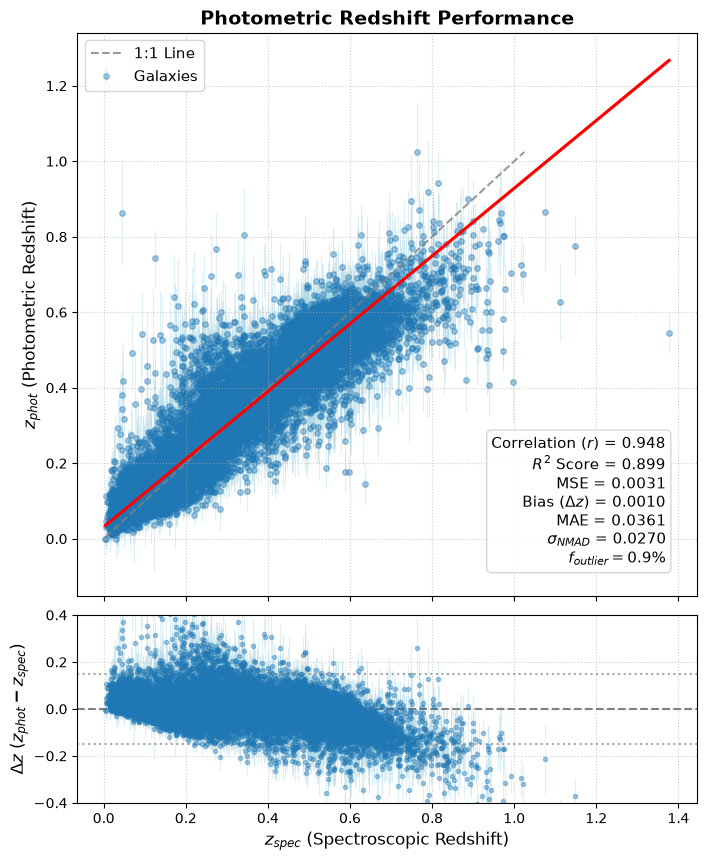

In [134]:
def plot_redshift_comparison(true_z, pred_z, pred_z_err=None):
    """
    繪製真實驗證紅移與推算測光紅移的比較圖，包含完整統計指標與殘差圖。
    """
    import seaborn as sns
    from scipy import stats
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
    
    # 過濾無效值 (NaN或無限大)
    valid_idx = np.isfinite(true_z) & np.isfinite(pred_z)
    x = true_z[valid_idx]
    y = pred_z[valid_idx]
    
    y_err = pred_z_err[valid_idx] if pred_z_err is not None else None
        
    # ================= 建立畫布與子圖 =================
    fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(8, 10), 
                                          gridspec_kw={'height_ratios': [3, 1]}, sharex=True)
    
    # ================= 1. 上半部主圖 (Main Plot) =================
    ax_main.errorbar(x, y, yerr=y_err, fmt='o', markersize=4, alpha=0.4, 
                     ecolor='lightblue', elinewidth=0.8, capsize=0, zorder=1, label='Galaxies')
    
    limits = [max(min(x), min(y)), min(max(x), max(y))]
    ax_main.plot(limits, limits, color='gray', linestyle='--', alpha=0.8, zorder=2, label='1:1 Line')
    
    sns.regplot(x=x, y=y, ax=ax_main, scatter=False, color='red', 
                line_kws={'label': 'Weighted Fit', 'zorder': 3})
    
    # ================= 🌟 計算更多統計指標 🌟 =================
    # 天文定義的紅移偏差 (Normalized residual): dz = (z_phot - z_spec) / (1 + z_spec)
    dz_norm = (y - x) / (1 + x) 
    
    # 1. 天文常用指標
    sigma_nmad = 1.48 * np.median(np.abs(dz_norm - np.median(dz_norm)))  # 歸一化絕對中位差 (更能抵抗離群值的標準差)
    f_outlier = np.sum(np.abs(dz_norm) > 0.15) / len(x) * 100            # 離群值比例 (誤差大於 15% 的比例)
    bias = np.median(dz_norm)                                            # 系統性偏差 (Median Bias，看整體是高估還低估)
    
    # 2. 統計學/機器學習常用指標
    r_val, _ = stats.pearsonr(x, y)                        # Pearson 相關係數 (r)，越接近 1 代表越呈直線相關
    r2 = r2_score(x, y)                                    # 決定係數 (R^2)，完美預測為 1.0
    mse = (mean_squared_error(x, y))               # 均方根誤差 (MSE)，模型整體的絕對誤差大小
    mae = mean_absolute_error(x, y)                    # 平均絕對誤差 (MAE)，模型整體的絕對誤差大小
    
    stats_text = (f"Correlation ($r$) = {r_val:.3f}\n"
                  f"$R^2$ Score = {r2:.3f}\n"
                  f"MSE = {mse:.4f}\n"
                  f"Bias ($\\Delta z$) = {bias:.4f}\n"
                  f"MAE = {mae:.4f}\n"
                  f"$\\sigma_{{NMAD}}$ = {sigma_nmad:.4f}\n"
                  f"$f_{{outlier}} = {f_outlier:.1f}\\%$")
    
    # 標註統計資訊
    props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='lightgray')
    ax_main.text(0.95, 0.05, stats_text, transform=ax_main.transAxes, fontsize=11,
                 verticalalignment='bottom', horizontalalignment='right', bbox=props, zorder=4)
    
    ax_main.set_title('Photometric Redshift Performance', fontsize=14, fontweight='bold')
    ax_main.set_ylabel('$z_{phot}$ (Photometric Redshift)', fontsize=12)
    ax_main.legend(loc='upper left', fontsize=11)
    ax_main.grid(True, linestyle=':', alpha=0.6)
    
    # ================= 2. 下半部殘差圖 (Residual Plot) =================
    ax_res.errorbar(x, y - x, yerr=y_err, fmt='o', markersize=3, alpha=0.4, ecolor='lightblue', elinewidth=0.8)
    ax_res.axhline(0, color='gray', linestyle='--', linewidth=1.5)
    
    ax_res.axhline(0.15, color='gray', linestyle=':', alpha=0.7)
    ax_res.axhline(-0.15, color='gray', linestyle=':', alpha=0.7)
    
    ax_res.set_xlabel('$z_{spec}$ (Spectroscopic Redshift)', fontsize=12)
    ax_res.set_ylabel('$\\Delta z$ ($z_{phot} - z_{spec}$)', fontsize=12)
    ax_res.set_ylim(-0.4, 0.4)
    ax_res.grid(True, linestyle=':', alpha=0.6)
    
    plt.subplots_adjust(hspace=0.05)
    import glob
    plt.savefig(f'../fig/photo_z_ps1_{len(glob.glob('../fig/*.png'))}.png', dpi = 300)
    plt.show()

# ==========================================
# 📊 [使用範例] 利用訓練集的一部分來進行驗證
# ==========================================

# print("正在抽取 500 筆訓練集資料進行自我驗證比較...")

# 1. 抽出驗證集特徵與真實的 z_spec
val_features = target_features_scaled
val_z_true = target_df['spec_redshift'].values
# k_best = 150
# 2. 使用 LLR 函數對這些驗證樣本進行紅移預測
val_z_pred, val_z_err, val_z_std = calculate_photometric_redshift_llr(
    train_features_scaled, 
    train_df['spec_redshift'], 
    val_features, 
    k=k_best
)

# 3. 呼叫繪圖函數畫出對比與迴歸區間
plot_redshift_comparison(val_z_true, val_z_pred, pred_z_err=val_z_err)


In [142]:
sigma_nmad_list = []
for i in np.linspace(0, 1, 100):
    valid_idx = val_z_std < (i)
    x = val_z_true[valid_idx]
    y = val_z_pred[valid_idx]
    dz_norm = (y - x) / (1 + x)
    sigma_nmad = 1.48 * np.median(np.abs(dz_norm - np.median(dz_norm)))
    sigma_nmad_list.append([i, sigma_nmad])
    print(f"在STD < {i*100:.2f}% 的情況下，σ_NMAD 為 {sigma_nmad:.5f}")

在STD < 0.00% 的情況下，σ_NMAD 為 nan
在STD < 1.01% 的情況下，σ_NMAD 為 nan
在STD < 2.02% 的情況下，σ_NMAD 為 0.01289
在STD < 3.03% 的情況下，σ_NMAD 為 0.01586
在STD < 4.04% 的情況下，σ_NMAD 為 0.01872
在STD < 5.05% 的情況下，σ_NMAD 為 0.02113
在STD < 6.06% 的情況下，σ_NMAD 為 0.02258
在STD < 7.07% 的情況下，σ_NMAD 為 0.02351
在STD < 8.08% 的情況下，σ_NMAD 為 0.02434
在STD < 9.09% 的情況下，σ_NMAD 為 0.02496
在STD < 10.10% 的情況下，σ_NMAD 為 0.02547
在STD < 11.11% 的情況下，σ_NMAD 為 0.02588
在STD < 12.12% 的情況下，σ_NMAD 為 0.02619
在STD < 13.13% 的情況下，σ_NMAD 為 0.02642
在STD < 14.14% 的情況下，σ_NMAD 為 0.02657
在STD < 15.15% 的情況下，σ_NMAD 為 0.02668
在STD < 16.16% 的情況下，σ_NMAD 為 0.02676
在STD < 17.17% 的情況下，σ_NMAD 為 0.02682
在STD < 18.18% 的情況下，σ_NMAD 為 0.02684
在STD < 19.19% 的情況下，σ_NMAD 為 0.02688
在STD < 20.20% 的情況下，σ_NMAD 為 0.02692
在STD < 21.21% 的情況下，σ_NMAD 為 0.02694
在STD < 22.22% 的情況下，σ_NMAD 為 0.02697
在STD < 23.23% 的情況下，σ_NMAD 為 0.02699
在STD < 24.24% 的情況下，σ_NMAD 為 0.02700
在STD < 25.25% 的情況下，σ_NMAD 為 0.02701
在STD < 26.26% 的情況下，σ_NMAD 為 0.02702
在STD < 27.27% 的情況下，σ_NMAD 為 0.02703
在STD < 28.

/data/TARA/astro13.venv/lib64/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/data/TARA/astro13.venv/lib64/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


20.868386878211282


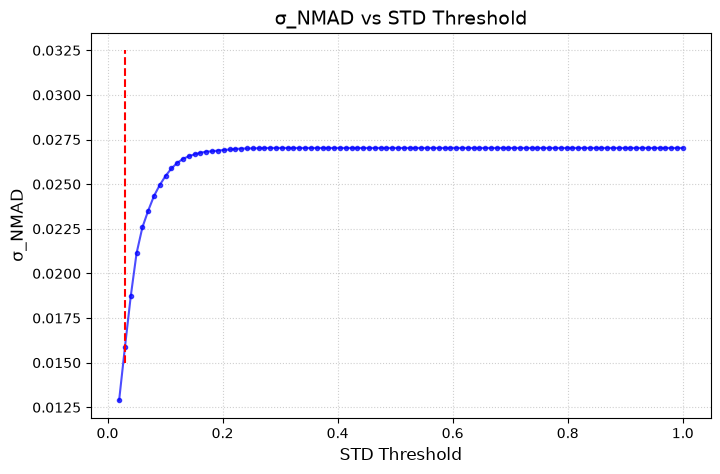

In [143]:
threshold = 0.03
print(len(val_z_std[val_z_std < threshold])/len(val_z_std)*100)
sigma_nmad_list = np.array(sigma_nmad_list)
plt.figure(figsize=(8, 5))
plt.plot((sigma_nmad_list[:, 0]), (sigma_nmad_list[:, 1]), marker='o', markersize=3, linestyle='-', color='blue', alpha=0.7)
plt.vlines(threshold, 0.015, 0.0325, color = 'r', linestyles= '--')
plt.title('σ_NMAD vs STD Threshold', fontsize=14)
plt.xlabel('STD Threshold', fontsize=12)
plt.ylabel('σ_NMAD', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
# plt.savefig(f'../fig/sigma_nmad_vs_std_{len(glob.glob("../fig/*.png"))}.png', dpi=300)
plt.show()


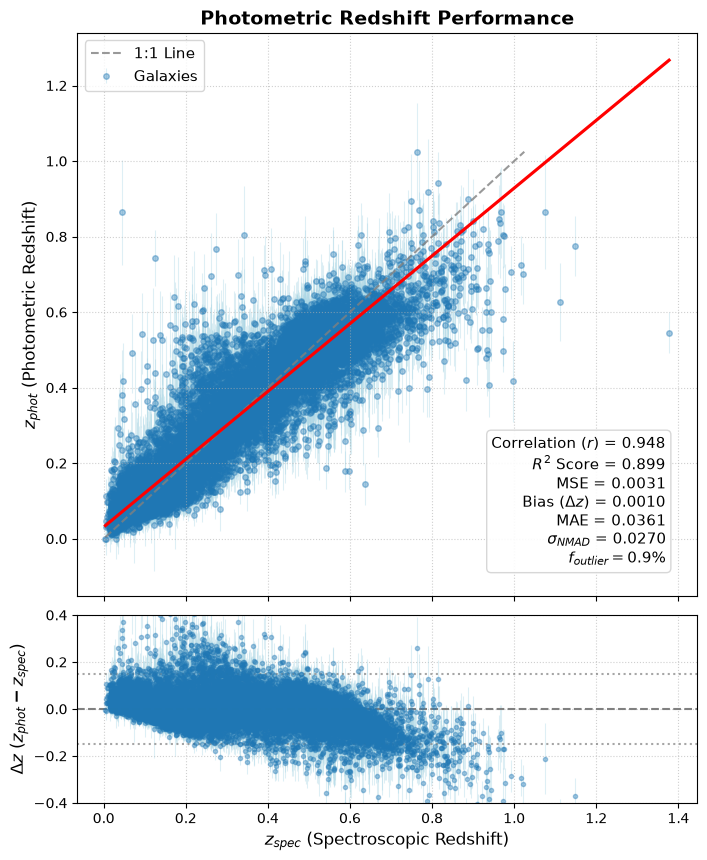

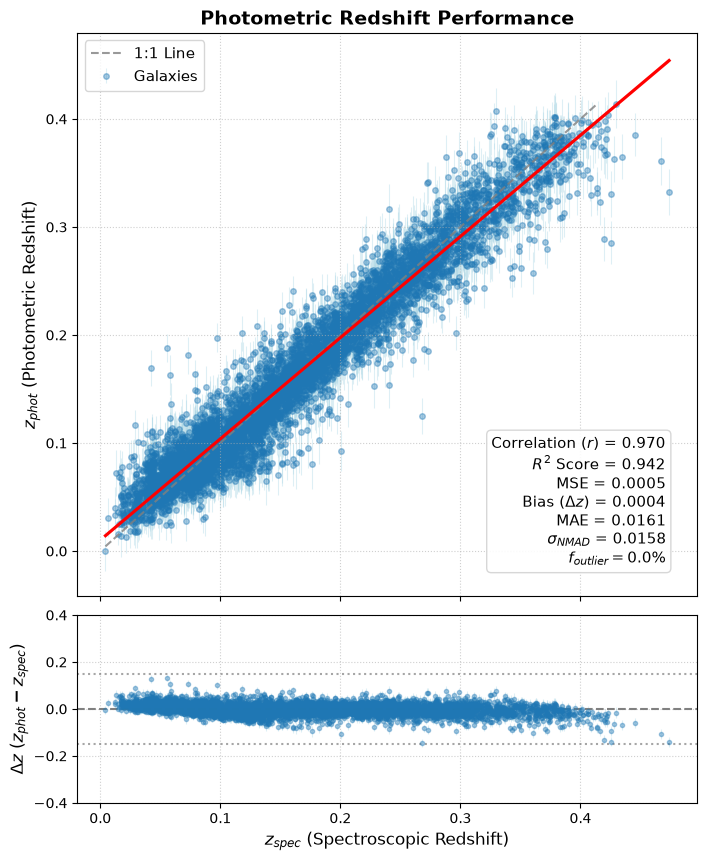

In [144]:
plot_redshift_comparison(val_z_true, val_z_pred, pred_z_err=val_z_err)
plot_redshift_comparison(val_z_true[val_z_std < threshold], val_z_pred[val_z_std < threshold], pred_z_err=val_z_err[val_z_std < threshold])
# plot_redshift_comparison(val_z_true[val_z_err < threshold], val_z_pred[val_z_err < threshold], pred_z_err=val_z_err[val_z_err < threshold])

In [54]:
import joblib

llr_model_data = {
    'scaler': scaler,
    'train_features_scaled': train_features_scaled,
    'train_z_spec': train_df['spec_redshift'],
    'k': k_best,
    'threshold': threshold
}
joblib.dump(llr_model_data, 'llr_model_package.pk1')
print('saved')

saved


In [5]:
from xgboost_distribution import XGBDistribution
from sklearn.model_selection import train_test_split
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# 1. 準備您的數據 (此部分維持原樣)
ml_data = df.copy()

def extract_features(df):
    """
    計算去紅化星等並提取 5 維度的特徵空間。
    """
    df = df.copy()
    bands = ['g', 'r', 'i', 'z', 'y']
    
    # 1. 去紅化計算
    sfd = SFDQuery()
    coords = SkyCoord(ra = df['raMean'], dec = df['decMean'], unit = (u.deg, u.deg), frame = 'icrs')
    ebv = sfd(coords)
    coefficient = [3.172, 2.271, 1.682, 1.322, 1.087]
    extinction = [i*ebv for i in coefficient]
    for b, extinc in zip(bands, extinction):
        if f'{b}Mean{MAG}Mag' in df.columns:
            df[f'dered_{b}'] = df[f'{b}Mean{MAG}Mag'] - extinc
        else:
            raise ValueError(f"缺少 {b} 波段的資料")
            
    # 2. 計算 5D 測光特徵空間
    features = pd.DataFrame()
    features['mag_r'] = df['dered_r']
    features['g-r'] = df['dered_g'] - df['dered_r']
    features['r-i'] = df['dered_r'] - df['dered_i']
    features['i-z'] = df['dered_i'] - df['dered_z']
    features['z-y'] = df['dered_z'] - df['dered_y']
    for b in bands:
        df[f'{b}_err'] = df[f'{b}Mean{MAG}MagErr']

    return df, features

# 計算特徵顏色
ml_data, ml_feature = extract_features(ml_data)

# 分離特徵 (X) 與目標 (y)
features = ml_feature
target = ml_data['spec_redshift']

print(f"準備使用 {len(ml_data)} 個星系進行機器學習訓練。")

# 假設您已經做完了資料清洗與 extract_features
# features, target = ml_feature, ml_data['spec_redshift']
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
# ================= 關鍵修改 =================
# 1. 訓練 XGBDistribution 模型
# 設定 distribution="normal"，模型會同時學習預測紅移的「期望值 (loc)」與「變異數/標準差 (scale)」
xgb_dist_model = XGBDistribution(
    distribution="normal", 
    n_estimators=500, 
    learning_rate=0.1, 
    max_depth=6, 
    n_jobs=-1
)
xgb_dist_model.fit(X_train, y_train)
# 2. 預測分佈參數
# 回傳的 preds 是一個包含預測參數的物件 (例如 preds.loc 是平均值, preds.scale 是標準差)
preds = xgb_dist_model.predict(X_test)
y_pred_mean = preds.loc    # 預測的紅移值 (PDF 的中心)
y_pred_std = preds.scale   # 預測的紅移不確定度 (PDF 的寬度)

準備使用 306671 個星系進行機器學習訓練。


In [7]:
from scipy.stats import norm as normal

# 計算連續 PDF 的數值 (畫圖用)
# pdf_values = laplace.pdf(z_grid, loc=mean_val, scale=std_val)

# 如果要用剛才超快速的 CDF 寫法算 Odds：
d_array = 0.03 * (1 + preds.loc)
odds_array = normal.cdf(preds.loc + d_array, loc=preds.loc, scale=preds.scale) - normal.cdf(preds.loc - d_array, loc=preds.loc, scale=preds.scale)
len(odds_array[odds_array > 0.82])/len(odds_array)*100

17.324529224749327

In [6]:
plot_redshift_comparison(y_test, y_pred_mean)
plot_redshift_comparison(y_test[odds_array > 0.82], y_pred_mean[odds_array > 0.82])

NameError: name 'plot_redshift_comparison' is not defined

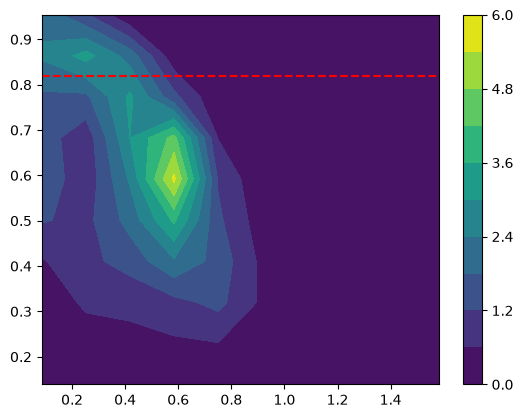

In [21]:
Z, x, y = np.histogram2d(y_test, odds_array, density=True)
x_centers = (x[:-1] + x[1:]) / 2
y_centers = (y[:-1] + y[1:]) / 2
X, Y = np.meshgrid(x_centers, y_centers)

plt.contourf(X, Y, Z.T, levels = 10)
plt.hlines(0.82, np.min(x_centers[0]), np.max(x_centers[-1]), color = 'r', linestyles='--')
plt.colorbar()
plt.show()

In [121]:
import joblib

# 將訓練好的模型存檔，副檔名通常使用 .pkl 或 .joblib
joblib.dump(xgb_dist_model, 'xgboost_photoz_model.pkl')

print("模型已成功保存為 'xgboost_photoz_model.pkl'！")

模型已成功保存為 'xgboost_photoz_model.pkl'！
